# Façade Material Segmentation & WWR Estimation
### YOLOv8 Instance Segmentation Pipeline

**Goals:**
1. Material ratios (e.g., 50% brick, 30% vinyl) via ML segmentation
2. WWR for curated images — calculated directly from Roboflow annotations (no ML needed)
3. WWR + materials for 5,000+ raw GSV images — ML detection with center-building isolation

**Two models are NOT needed.** One model detects 8 classes: acm, brick, dec_stone, fibercement, metal, stucco, vinyl, window. No facade class (it causes training confusion due to overlapping with material masks).

**Before running:** Runtime → Change runtime type → T4 GPU

---
## Part 1: Setup & Data

In [ ]:
# ============================================================
# Cell 1: Verify GPU
# ============================================================
!nvidia-smi

Wed Apr  8 13:19:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ============================================================
# Cell 2: Install dependencies
# ============================================================
!pip install ultralytics roboflow shapely -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Cell 3: Import libraries
# ============================================================
import os
import json
import glob
import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow
from shapely.geometry import Polygon
from IPython.display import Image, display
from google.colab import files, drive

HOME = os.getcwd()
print(f"Working directory: {HOME}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Working directory: /content
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
# ============================================================
# Cell 4: Mount Google Drive
# ============================================================
# Your curated images, raw GSV images, and COCO annotation JSON
# should be uploaded to Google Drive.

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Cell 5: Download TRAINING dataset from Roboflow
# ============================================================
# This is your ML project with 8 classes (NO facade, NO ignore):
# acm, brick, dec_stone, fibercement, metal, stucco, vinyl, window
#
# REPLACE with your values from Roboflow export page:

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="rTmhjspZQskMqb2jvrlh")  # <-- paste your key
project = rf.workspace("circle-lab").project("gsv-facade-detection-3-only-material-classes")
version = project.version(6)
dataset = version.download("yolov8")  # <-- update version number

print(f"\nDataset location: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to GSV-Facade-Detection-3---only-material-classes-6 in yolov8:: 100%|██████████| 1200/1200 [00:00<00:00, 2337.54it/s]



Dataset location: /content/GSV-Facade-Detection-3---only-material-classes-6


In [ ]:
# ============================================================
# Cell 6: Verify dataset — should show 8 classes, no facade
# ============================================================
print("=" * 50)
print("DATA.YAML CONTENTS:")
print("=" * 50)
!cat {dataset.location}/data.yaml

print("\n" + "=" * 50)
print("IMAGE COUNTS PER SPLIT:")
print("=" * 50)
for split in ["train", "valid", "test"]:
    path = os.path.join(dataset.location, split, "images")
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"  {split}: {count} images")
    else:
        print(f"  {split}: folder not found")

DATA.YAML CONTENTS:
names:
- acm
- brick
- dec_stone
- fibercement
- metal
- stucco
- vinyl
- window
nc: 8
roboflow:
  license: Private
  project: gsv-facade-detection-3-only-material-classes
  url: https://app.roboflow.com/circle-lab/gsv-facade-detection-3-only-material-classes/6
  version: 6
  workspace: circle-lab
test: ../test/images
train: ../train/images
val: ../valid/images

IMAGE COUNTS PER SPLIT:
  train: 489 images
  valid: 55 images
  test: 54 images


**Checkpoint:** You should see 8 classes: acm, brick, dec_stone, fibercement, metal, stucco, vinyl, window. NO facade, NO ignore.

---
## Part 2: Train the Model

In [ ]:
# ============================================================
# Cell 7: Train YOLOv8m-seg (with auto-save to Google Drive)
# ============================================================
# This cell does THREE things:
#   1. Connects to Google Drive (so we can save the model there)
#   2. Trains the model
#   3. Copies the trained weights to Drive immediately after

import shutil, os
from google.colab import drive

# --- STEP 1: Connect Google Drive ---
drive.mount('/content/drive')
save_dir = "/content/drive/MyDrive/facade_model_backup/"
os.makedirs(save_dir, exist_ok=True)
print("Google Drive connected. Model will be saved after training.\n")

# --- STEP 2: Train ---

model = YOLO("yolov8m-seg.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=200,          # increase if using Colab Pro
    patience=50,         # early stopping
    imgsz=1280,          # high res for texture detail
    batch=8,             # reduce to 4 if memory error
    device=0,
    name="facade_seg",

    # Augmentation
    flipud=0.0,          # no vertical flip
    fliplr=0.5,          # horizontal flip
    mosaic=1.0,          # mosaic augmentation
    mixup=0.1,           # slight blending
    degrees=10.0,        # rotation
    hsv_h=0.015,         # hue shift
    hsv_s=0.4,           # saturation
    hsv_v=0.4,           # brightness
)

# --- STEP 3: Save to Drive immediately ---
shutil.copy(f"{HOME}/runs/segment/facade_seg/weights/best.pt",
            f"{save_dir}/best.pt")
shutil.copy(f"{HOME}/runs/segment/facade_seg/weights/last.pt",
            f"{save_dir}/last.pt")
shutil.copytree(f"{HOME}/runs/segment/facade_seg",
                f"{save_dir}/full_results", dirs_exist_ok=True)

print("\n" + "=" * 50)
print("TRAINING COMPLETE!")
print("=" * 50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected. Model will be saved after training.

Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/GSV-Facade-Detection-3---only-material-classes-6/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_

---
## Part 3: Evaluate the Model

In [ ]:
# ============================================================
# Cell 8: Validate
# ============================================================
# Load from Google Drive (survives disconnections)
best_model = YOLO("/content/drive/MyDrive/facade_model_backup/best.pt")
metrics = best_model.val(data=f"{dataset.location}/data.yaml")

print("\n" + "=" * 50)
print("OVERALL RESULTS")
print("=" * 50)
print(f"  Mask mAP50:    {metrics.seg.map50:.4f}")
print(f"  Mask mAP50-95: {metrics.seg.map:.4f}")

Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,227,016 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2006.0±404.2 MB/s, size: 186.4 KB)
val: Scanning /content/GSV-Facade-Detection-3---only-material-classes-6/valid/labels... 55 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 55/55 405.2it/s 0.1s
val: New cache created: /content/GSV-Facade-Detection-3---only-material-classes-6/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.7s/it 14.9s
                   all         55        356      0.815      0.797       0.84      0.572      0.817      0.789      0.835      0.527
                   acm          7          7          1      0.928      0.995      0.821          1      0.923      0.995       0.74
                 brick         38        

In [ ]:
# ============================================================
# Cell 9: Training curves
# ============================================================
print("Training curves (loss should go down, metrics should go up):")
display(Image(filename=f"{HOME}/runs/segment/facade_seg/results.png", width=900))

Training curves (loss should go down, metrics should go up):


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/segment/facade_seg/results.png'

In [ ]:
# ============================================================
# Cell 10: Confusion matrix
# ============================================================
print("Confusion matrix:")
display(Image(filename=f"{HOME}/runs/segment/facade_seg/confusion_matrix.png", width=800))

Confusion matrix:


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/segment/facade_seg/confusion_matrix.png'

In [ ]:
# ============================================================
# Cell 11: Sample predictions
# ============================================================
val_pred_path = f"{HOME}/runs/segment/facade_seg/val_batch0_pred.jpg"
if os.path.exists(val_pred_path):
    display(Image(filename=val_pred_path, width=900))
else:
    print("Prediction visualization not found.")

Prediction visualization not found.


In [ ]:
import time

drive_results = "/content/drive/MyDrive/facade_model_backup/full_results/"

# Check when files were last modified to make sure results are not from previous training
for f in ["best.pt", "results.png", "confusion_matrix.png"]:
    path = os.path.join(drive_results, f)
    if os.path.exists(path):
        mod_time = time.ctime(os.path.getmtime(path))
        print(f"  {f}: {mod_time}")

# Also check the weights file directly
weights_path = "/content/drive/MyDrive/facade_model_backup/best.pt"
mod_time = time.ctime(os.path.getmtime(weights_path))
print(f"\n  best.pt (main): {mod_time}")

  results.png: Wed Apr  8 08:19:41 2026
  confusion_matrix.png: Wed Apr  8 14:04:35 2026

  best.pt (main): Wed Apr  8 08:19:33 2026


Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,227,016 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2432.5±535.8 MB/s, size: 184.8 KB)
val: Scanning /content/GSV-Facade-Detection-3---only-material-classes-6/valid/labels.cache... 55 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 55/55 13.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.5s/it 14.1s
                   all         55        356      0.815      0.797       0.84      0.572      0.817      0.789      0.835      0.527
                   acm          7          7          1      0.928      0.995      0.821          1      0.923      0.995       0.74
                 brick         38         39      0.857       0.77      0.874       0.31       0.86      0.744      0.836      0.305
   

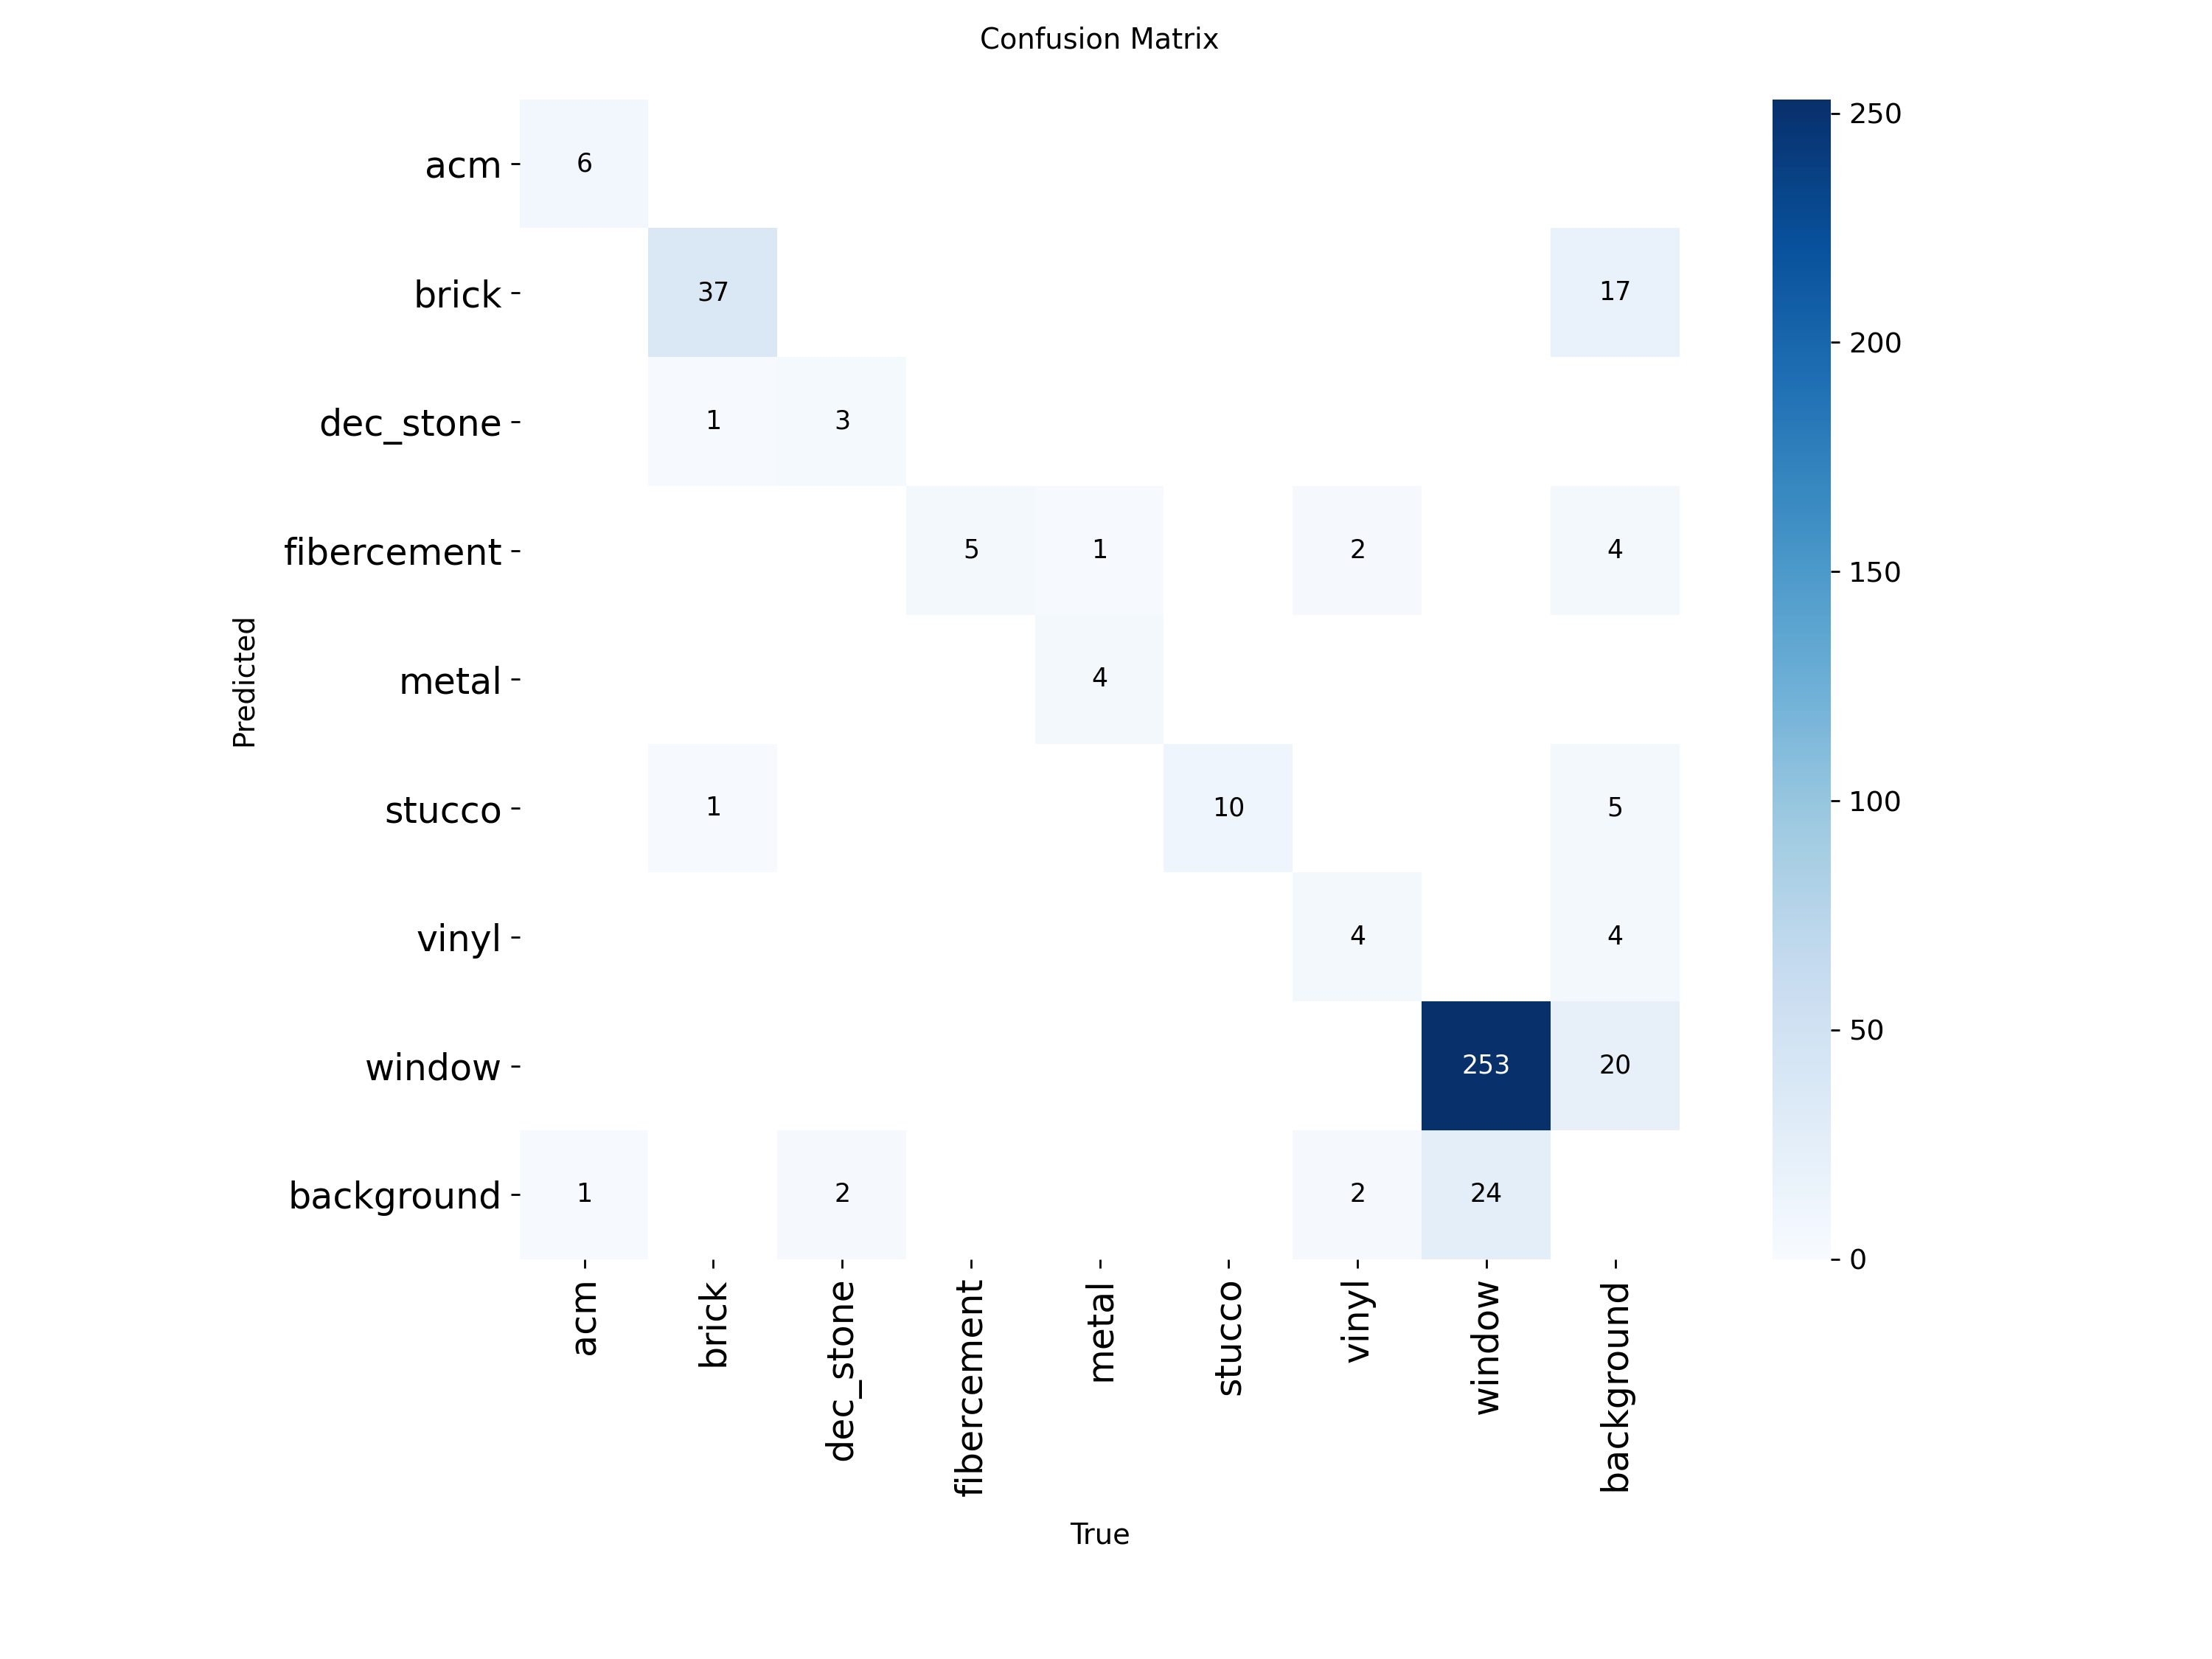


Sample predictions:


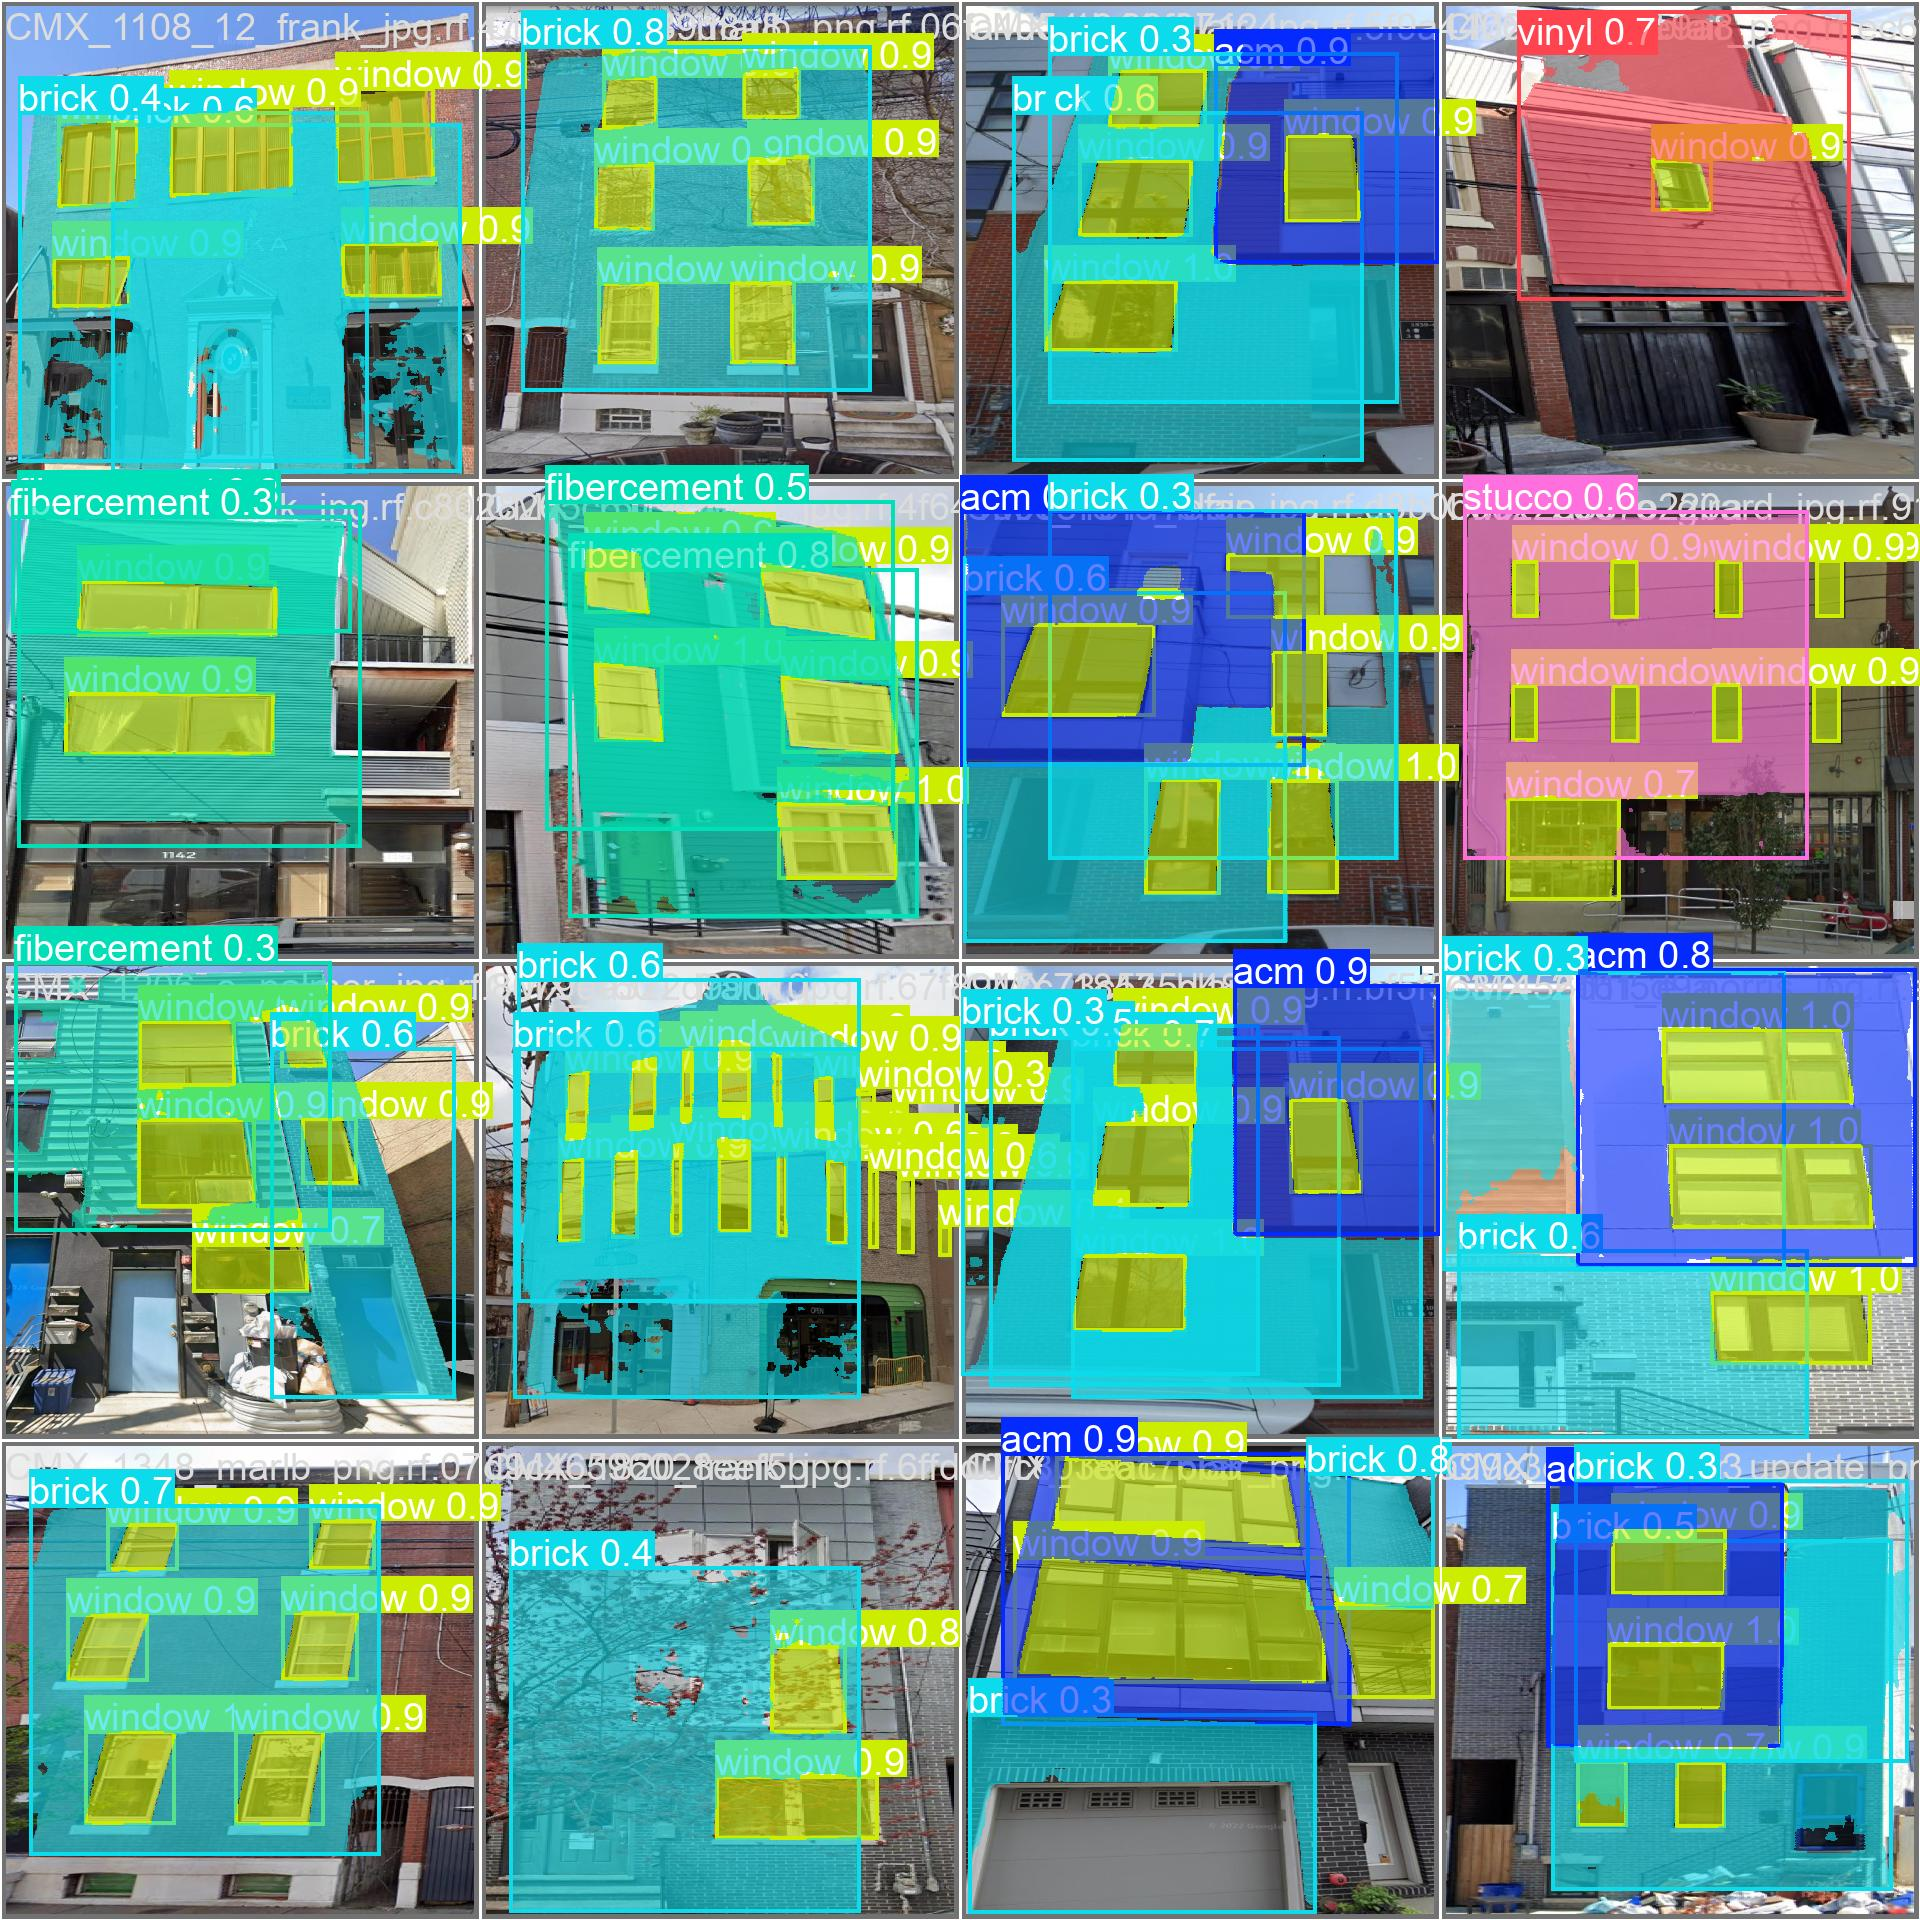

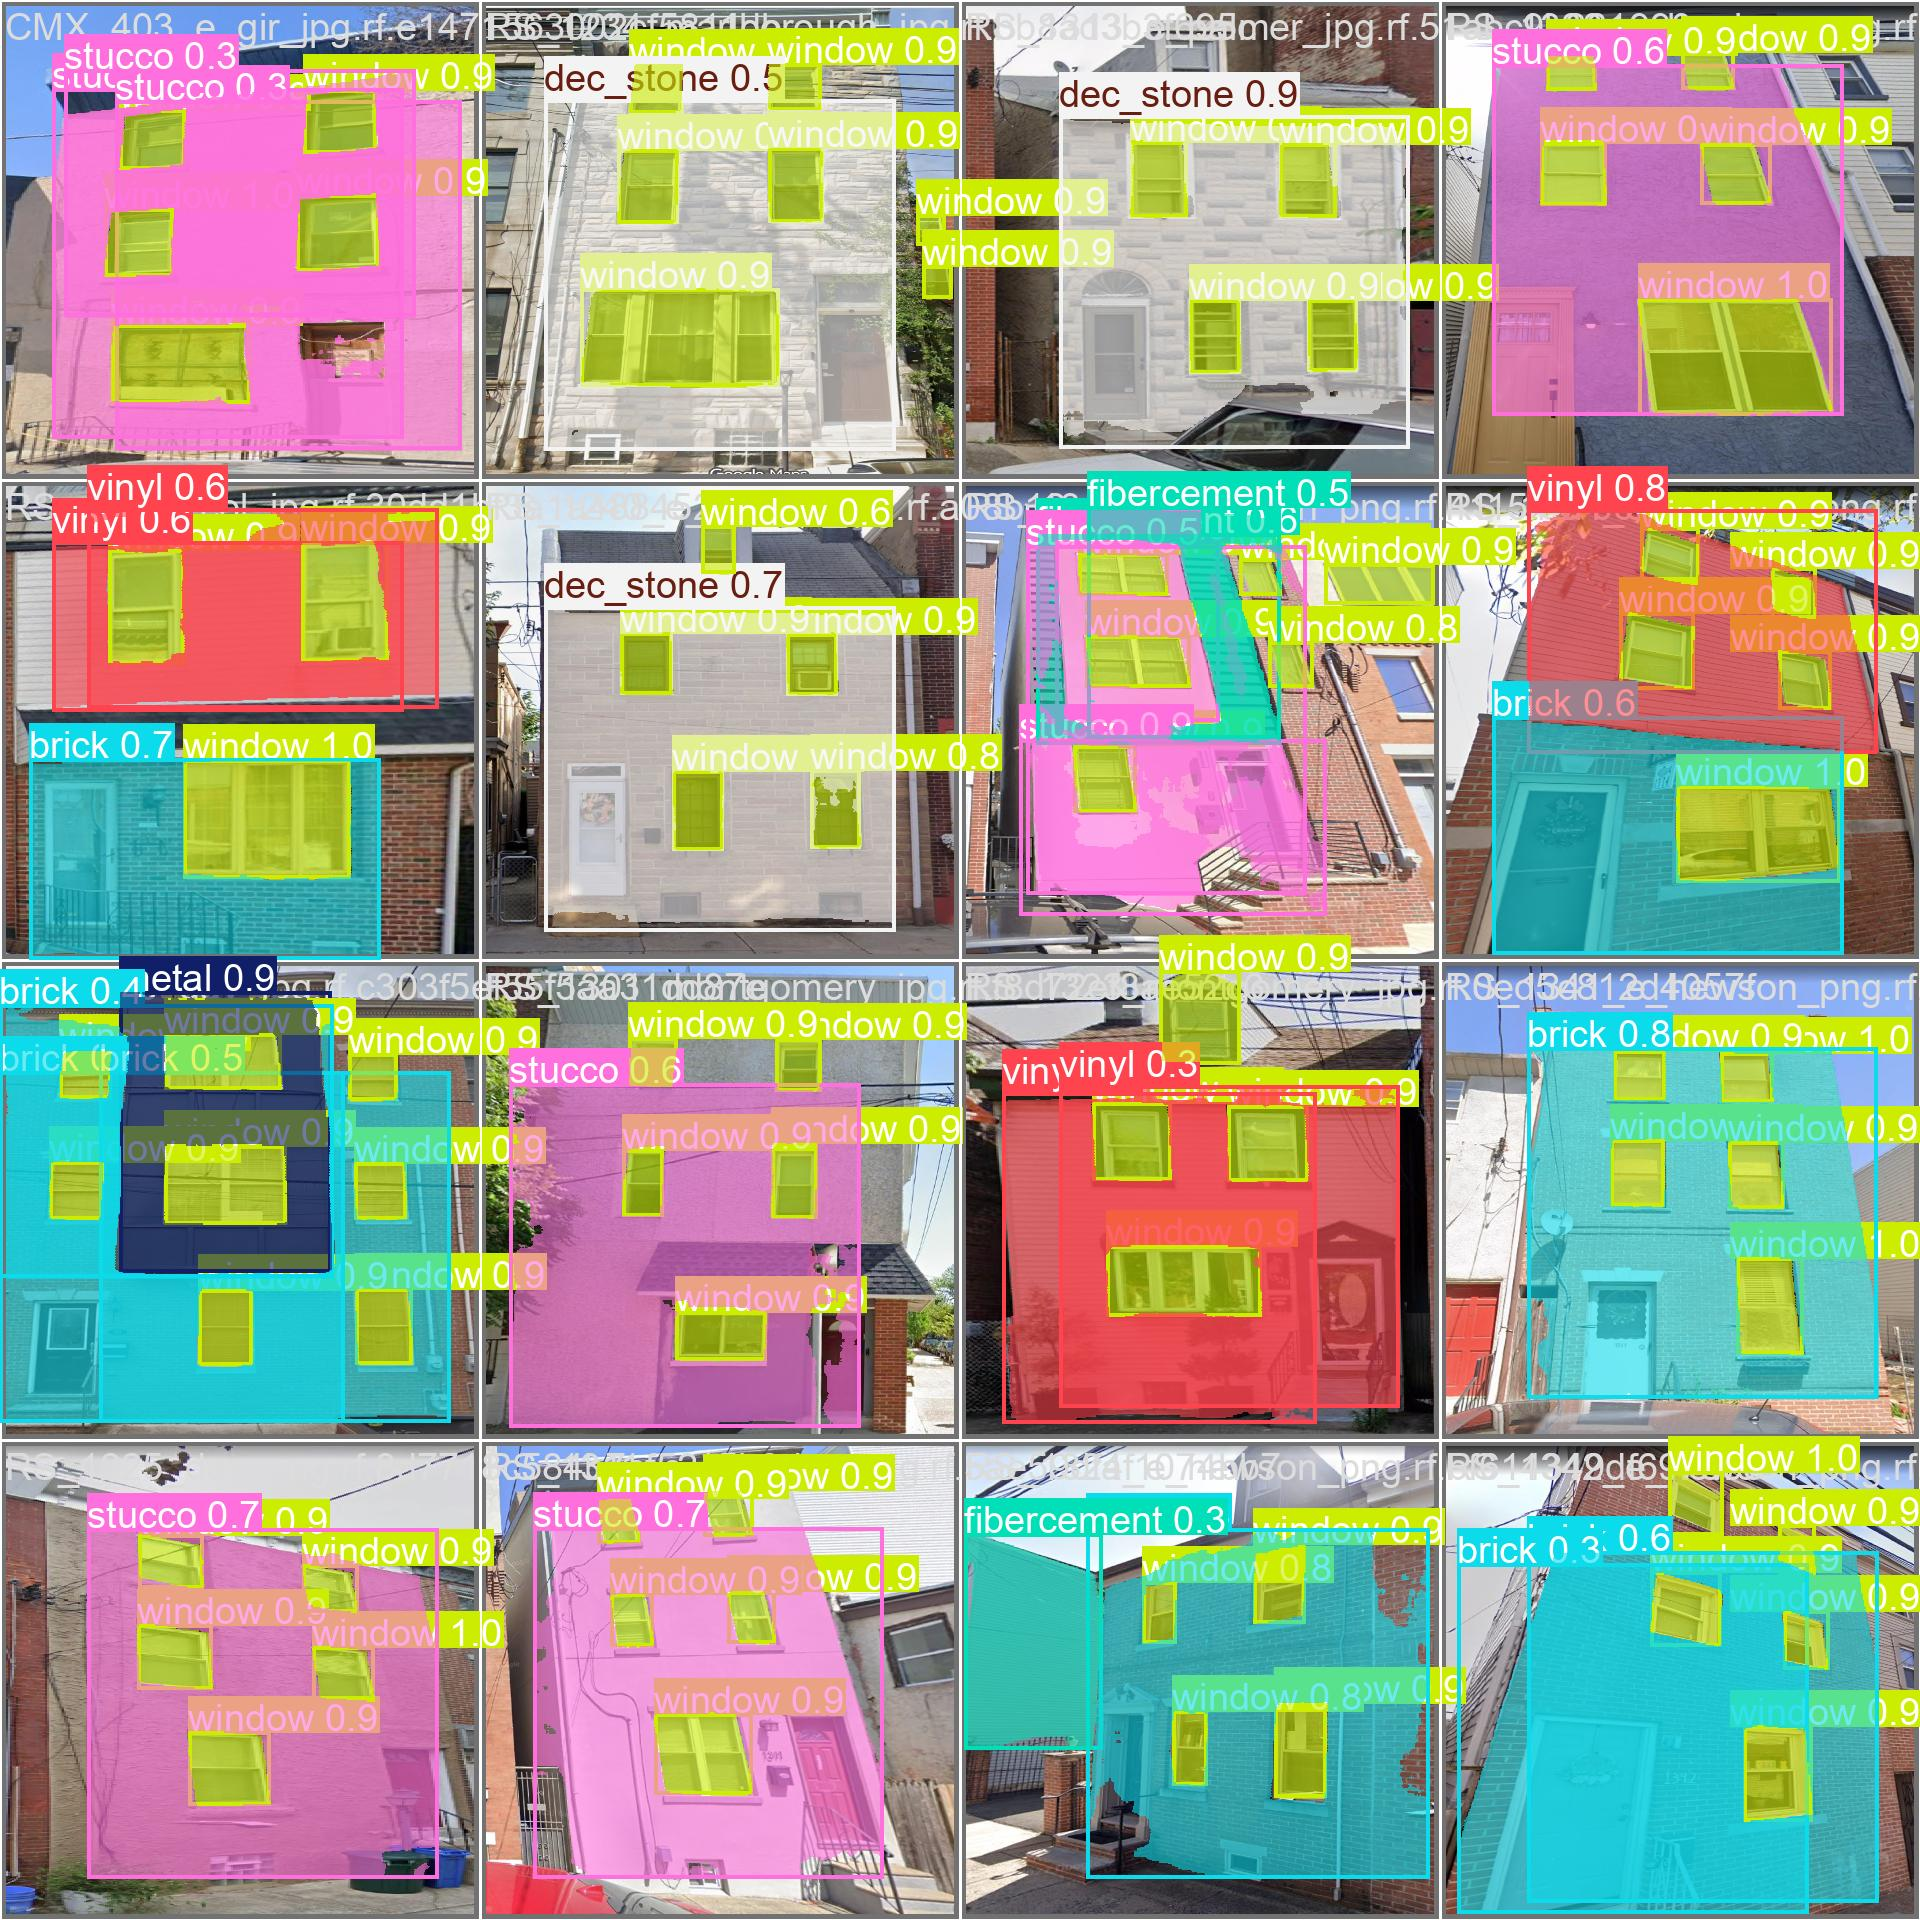


All visuals saved to Drive: /content/drive/MyDrive/facade_model_backup/latest_visuals/


In [ ]:
best_model = YOLO("/content/drive/MyDrive/facade_model_backup/best.pt")

# This regenerates confusion matrix, per-class results, AND sample predictions from the saved memory
metrics = best_model.val(
    data=f"{dataset.location}/data.yaml",
    save=True,
    plots=True
)

# Find where it saved
save_path = metrics.save_dir
print(f"Results saved to: {save_path}")

# Display everything
from IPython.display import Image, display

print("\nTraining curves (only available if from original training):")
if os.path.exists(f"{save_path}/results.png"):
    display(Image(filename=f"{save_path}/results.png", width=900))

print("\nConfusion matrix:")
display(Image(filename=f"{save_path}/confusion_matrix.png", width=800))

print("\nSample predictions:")
for pred_file in ["val_batch0_pred.jpg", "val_batch1_pred.jpg"]:
    pred_path = f"{save_path}/{pred_file}"
    if os.path.exists(pred_path):
        display(Image(filename=pred_path, width=900))

# Save these to Drive so you never lose them again
import shutil
drive_viz = "/content/drive/MyDrive/facade_model_backup/latest_visuals/"
shutil.copytree(save_path, drive_viz, dirs_exist_ok=True)
print(f"\nAll visuals saved to Drive: {drive_viz}")

---
## Part 4: Define Inference Functions

In [ ]:
# ============================================================
# Cell 12: Constants
# ============================================================
MATERIAL_CLASSES = {"acm", "brick", "dec_stone", "fibercement",
                    "metal", "stucco", "vinyl"}

ALL_MATERIALS = sorted(list(MATERIAL_CLASSES))
print(f"Material classes: {ALL_MATERIALS}")

Material classes: ['acm', 'brick', 'dec_stone', 'fibercement', 'metal', 'stucco', 'vinyl']


In [ ]:
# ============================================================
# Cell 13: Material Ratios (ML-based, for any image)
# ============================================================

def get_material_ratios(model, image_path):
    """
    Detect materials and return area percentages.
    Percentages are relative to total material area (excludes windows).
    Example: {"brick": 62.4, "vinyl": 28.1, "stucco": 9.5}
    """
    results = model.predict(image_path, imgsz=1280, conf=0.25,
                            retina_masks=True, verbose=False)[0]
    class_names = model.names
    material_areas = {}

    if results.masks is not None:
        for i, mask in enumerate(results.masks.data):
            class_name = class_names[int(results.boxes.cls[i])]

            if class_name in MATERIAL_CLASSES:
                pixel_count = mask.sum().item()
                if class_name in material_areas:
                    material_areas[class_name] += pixel_count
                else:
                    material_areas[class_name] = pixel_count

    total = sum(material_areas.values())
    if total == 0:
        return {}

    ratios = {}
    for mat, area in material_areas.items():
        ratios[mat] = round((area / total) * 100, 1)

    return ratios

In [ ]:
# ============================================================
# Cell 14: WWR from ML predictions (for raw GSV images)
# ============================================================
# Since we removed the facade class, we calculate facade area as
# the sum of all detected regions (materials + windows).
# WWR = window area / (material area + window area)

def get_wwr_from_predictions(model, image_path):
    """
    Calculate WWR from ML predictions.
    Facade area = all material masks + all window masks combined.
    Returns float (e.g., 0.234 = 23.4% windows) or None.
    """
    results = model.predict(image_path, imgsz=1280, conf=0.25,
                            retina_masks=True, verbose=False)[0]
    class_names = model.names

    total_facade_area = 0
    window_area = 0

    if results.masks is not None:
        for i, mask in enumerate(results.masks.data):
            class_name = class_names[int(results.boxes.cls[i])]
            pixel_count = mask.sum().item()

            if class_name == "window":
                window_area += pixel_count
                total_facade_area += pixel_count
            elif class_name in MATERIAL_CLASSES:
                total_facade_area += pixel_count

    if total_facade_area == 0:
        return None

    return round(window_area / total_facade_area, 3)

In [ ]:
# ============================================================
# Cell 15: Center Building Analysis (for raw GSV images)
# ============================================================
# For raw GSV images with 3-6 rowhouses side by side.
# Since we have no facade class, we cluster nearby detections
# and pick the cluster closest to image center.

def analyze_center_building(model, image_path):
    """
    1. Detect all materials and windows in the full GSV image
    2. Find the largest material detection closest to image center
       (this anchors us to the center building)
    3. Keep only detections within that building's horizontal zone
    4. Compute material ratios and WWR for that building only
    """
    results = model.predict(image_path, imgsz=1280, conf=0.25,
                            retina_masks=True, verbose=False)[0]
    class_names = model.names

    empty_result = {
        "materials": {}, "wwr": None,
        "dominant_material": None, "status": "no_detections"
    }

    if results.masks is None:
        return empty_result

    # Get image dimensions
    img = cv2.imread(image_path)
    img_h, img_w = img.shape[:2]
    img_center_x = img_w / 2

    # ---- Collect all detections with spatial info ----
    detections = []
    for i, mask in enumerate(results.masks.data):
        class_name = class_names[int(results.boxes.cls[i])]
        if class_name not in MATERIAL_CLASSES and class_name != "window":
            continue

        box = results.boxes.xyxy[i]
        box_center_x = ((box[0] + box[2]) / 2).item()
        box_left = box[0].item()
        box_right = box[2].item()

        mask_resized = torch.nn.functional.interpolate(
            mask.unsqueeze(0).unsqueeze(0).float(),
            size=(img_h, img_w), mode='nearest'
        ).squeeze().cpu().numpy()

        detections.append({
            "class_name": class_name,
            "center_x": box_center_x,
            "left": box_left,
            "right": box_right,
            "mask": mask_resized,
            "area": mask_resized.sum()
        })

    if not detections:
        return empty_result

    # ---- Find anchor: largest material near image center ----
    material_dets = [d for d in detections if d["class_name"] in MATERIAL_CLASSES]

    if not material_dets:
        empty_result["status"] = "no_materials_found"
        return empty_result

    # Sort by distance to center, then pick the closest one
    anchor = min(material_dets, key=lambda d: abs(d["center_x"] - img_center_x))

    # ---- Define center building zone ----
    # Horizontal span of anchor material ± 20% margin
    span = anchor["right"] - anchor["left"]
    margin = span * 0.2
    zone_left = anchor["left"] - margin
    zone_right = anchor["right"] + margin

    # ---- Collect detections within the zone ----
    material_areas = {}
    window_area = 0

    for d in detections:
        # Skip detections whose center is outside the zone
        if d["center_x"] < zone_left or d["center_x"] > zone_right:
            continue

        if d["class_name"] in MATERIAL_CLASSES:
            if d["class_name"] in material_areas:
                material_areas[d["class_name"]] += d["area"]
            else:
                material_areas[d["class_name"]] = d["area"]
        elif d["class_name"] == "window":
            window_area += d["area"]

    # ---- Material ratios ----
    total_material = sum(material_areas.values())
    ratios = {}
    if total_material > 0:
        for mat, area in material_areas.items():
            ratios[mat] = round((area / total_material) * 100, 1)

    # ---- WWR ----
    total_facade = total_material + window_area
    wwr = round(window_area / total_facade, 3) if total_facade > 0 else None

    dominant = max(ratios, key=ratios.get) if ratios else None

    return {
        "materials": ratios,
        "wwr": wwr,
        "dominant_material": dominant,
        "status": "success"
    }

---
## Part 5: WWR from Roboflow Annotations (Curated Images — No ML)

For your ~400 curated images, you already drew facade and window polygons in Roboflow. WWR can be calculated directly from those annotations with zero ML error.

**How to get the annotation file:**
1. Go to your **original** Roboflow project (the one that still has facade + window classes)
2. Generate/export a version in **COCO Segmentation** format (the JSON option)
3. Download the JSON file and upload it to Google Drive
4. Set the path below

In [ ]:
# ============================================================
# Cell 16: Calculate WWR from Roboflow annotations (no ML)
# ============================================================
# SET THIS PATH to your COCO Segmentation JSON from the original
# Roboflow project (the one with facade + window annotations).
#
# The export folder usually contains:
#   train/_annotations.coco.json
#   valid/_annotations.coco.json
#   test/_annotations.coco.json
#
# Process all three to get WWR for your entire curated dataset.

def calculate_wwr_from_annotations(coco_json_path):
    """
    Calculate WWR directly from COCO annotation polygons.
    Returns a DataFrame with filename, facade_area, window_area, wwr.
    """
    with open(coco_json_path) as f:
        coco = json.load(f)

    # Build lookups
    categories = {c["id"]: c["name"] for c in coco["categories"]}
    images = {img["id"]: img["file_name"] for img in coco["images"]}

    # Group annotations by image
    image_data = {}
    for img_id, filename in images.items():
        image_data[img_id] = {
            "filename": filename,
            "facade_area": 0,
            "window_area": 0
        }

    for ann in coco["annotations"]:
        img_id = ann["image_id"]
        cat_name = categories[ann["category_id"]]

        # Calculate polygon area using Shapely
        for seg in ann["segmentation"]:
            # COCO format: [x1, y1, x2, y2, x3, y3, ...]
            points = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]

            if len(points) < 3:
                continue  # need at least 3 points for a polygon

            try:
                poly = Polygon(points)
                if poly.is_valid:
                    area = poly.area
                else:
                    # Fix self-intersecting polygons
                    area = poly.buffer(0).area

                if cat_name == "facade":
                    image_data[img_id]["facade_area"] += area
                elif cat_name == "window":
                    image_data[img_id]["window_area"] += area
            except Exception as e:
                print(f"  Warning: skipped polygon in {images[img_id]}: {e}")

    # Calculate WWR
    rows = []
    for img_id, data in image_data.items():
        wwr = None
        if data["facade_area"] > 0:
            wwr = round(data["window_area"] / data["facade_area"], 3)

        rows.append({
            "filename": data["filename"],
            "facade_area_px": round(data["facade_area"], 1),
            "window_area_px": round(data["window_area"], 1),
            "wwr": wwr
        })

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# Cell 17: Run WWR calculation on all annotation splits
# ============================================================
# SET THIS PATH to where you downloaded the COCO export:
coco_export_folder = "/content/drive/MyDrive/Facade Material Seg/GSV Facade detection 2 coco seg" #"/content/drive/MyDrive/YOUR_COCO_EXPORT_FOLDER/"  # <-- update

all_wwr_dfs = []

for split in ["train", "valid", "test"]:
    json_path = os.path.join(coco_export_folder, split, "_annotations.coco.json")
    if os.path.exists(json_path):
        print(f"Processing {split} split...")
        df_split = calculate_wwr_from_annotations(json_path)
        df_split["split"] = split
        all_wwr_dfs.append(df_split)
        print(f"  {len(df_split)} images, avg WWR: {df_split['wwr'].mean():.3f}")
    else:
        print(f"  {split} JSON not found at {json_path}")

df_wwr_annotations = pd.concat(all_wwr_dfs, ignore_index=True)
df_wwr_annotations.to_csv("curated_wwr_from_annotations.csv", index=False)

print(f"\n{'=' * 50}")
print("CURATED WWR RESULTS (from annotations, no ML)")
print(f"{'=' * 50}")
print(f"Total images: {len(df_wwr_annotations)}")
print(f"Images with valid WWR: {df_wwr_annotations['wwr'].notna().sum()}")
print(f"Average WWR: {df_wwr_annotations['wwr'].mean():.3f}")
print(f"Min WWR: {df_wwr_annotations['wwr'].min():.3f}")
print(f"Max WWR: {df_wwr_annotations['wwr'].max():.3f}")
print(f"\nFirst 10 rows:")
df_wwr_annotations.head(10)

Processing train split...
  373 images, avg WWR: 0.173
Processing valid split...
  56 images, avg WWR: 0.166
Processing test split...
  54 images, avg WWR: 0.176

CURATED WWR RESULTS (from annotations, no ML)
Total images: 483
Images with valid WWR: 481
Average WWR: 0.173
Min WWR: 0.000
Max WWR: 0.478

First 10 rows:


,filename,facade_area_px,window_area_px,wwr,split
0,RS_1345_montgomery_jpg.rf.4e9394407a4d5040ac39...,1253115.2,222231.2,0.177,train
1,CMX_2216_frank_update_jpg.rf.dfeb7ea70c3f223f9...,1079351.2,142857.4,0.132,train
2,CMX_1853_blair_png.rf.2d904c976437a8a7e8a48812...,744044.8,167003.4,0.224,train
3,RS_1310_e_hewson_png.rf.9d0d862373b10a0ece02d8...,1098342.6,117272.0,0.107,train
4,RS_1118_ecol_jpg.rf.0bb9e7e6d2c3d03318959291ed...,1366765.7,114876.4,0.084,train
5,RS_2218_almond_jpg.rf.2aa2c1766cf9701796c062ab...,1258111.7,246864.5,0.196,train
6,CMX_1832_frank_jpg.rf.fcf29fbb25f85ce2dd56d03b...,1425309.1,293455.7,0.206,train
7,CMX_2220_22_e_sus_jpg.rf.39a229d74df8cd029d7b3...,1423031.8,308314.3,0.217,train
8,CMX_451_e_gir_jpg.rf.8f64fa415017d9801684eab11...,1431460.0,176036.7,0.123,train
9,RS_2207_almond_jpg.rf.e7146e7c1771159d195b2dd5...,1257680.5,243027.1,0.193,train


---
## Part 6: Material Ratios for Curated Images (ML-based)

In [ ]:
# ============================================================
# Cell 18: Test on a single image first
# ============================================================
# Load from Google Drive (survives disconnections)

# Load from Google Drive (survives disconnections)
best_model = YOLO("/content/drive/MyDrive/facade_model_backup/best.pt") #MAKE SURE THE PATH IS CORRECT


test_img_folder = f"{dataset.location}/valid/images/"
test_images = os.listdir(test_img_folder)
sample_img = os.path.join(test_img_folder, test_images[0])

print(f"Testing on: {test_images[0]}")
print(f"Material ratios: {get_material_ratios(best_model, sample_img)}")
print(f"WWR (from ML): {get_wwr_from_predictions(best_model, sample_img)}")

# Visualize
viz = best_model.predict(sample_img, imgsz=1280, conf=0.25,
                          retina_masks=True, save=True)
print("Prediction saved to runs/segment/predict/")

Testing on: RS_2318_e_norris_jpg.rf.4c1c27d217e693b60cda6a000c9bf570.jpg
Material ratios: {'dec_stone': 77.2, 'brick': 22.8}
WWR (from ML): 0.105
Results saved to /content/runs/segment/predict2
Prediction saved to runs/segment/predict/


In [ ]:
# ============================================================
# Cell 19: Process all curated images for material ratios
# ============================================================
# SET YOUR PATH:
curated_folder = "/content/drive/MyDrive/Facade Material Seg/curated images_merged"  # <-- update

image_files = glob.glob(os.path.join(curated_folder, "*.jpg")) + \
              glob.glob(os.path.join(curated_folder, "*.png")) + \
              glob.glob(os.path.join(curated_folder, "*.jpeg"))

print(f"Found {len(image_files)} curated images")

curated_results = []

for i, img_path in enumerate(image_files):
    if i % 50 == 0:
        print(f"Processing {i}/{len(image_files)}...")

    materials = get_material_ratios(best_model, img_path)

    row = {
        "filename": os.path.basename(img_path),
        "dominant_material": max(materials, key=materials.get) if materials else None,
    }
    for mat in ALL_MATERIALS:
        row[f"pct_{mat}"] = materials.get(mat, 0.0)

    curated_results.append(row)

df_curated_materials = pd.DataFrame(curated_results)
df_curated_materials.to_csv("curated_material_ratios.csv", index=False)

print(f"\n{'=' * 50}")
print("CURATED MATERIAL RATIOS")
print(f"{'=' * 50}")
print(f"Total: {len(df_curated_materials)}")
print(f"\nDominant material distribution:")
print(df_curated_materials["dominant_material"].value_counts().to_string())
print(f"\nFirst 10 rows:")
df_curated_materials.head(10)

Found 477 curated images
Processing 0/477...
Processing 50/477...
Processing 100/477...
Processing 150/477...
Processing 200/477...
Processing 250/477...
Processing 300/477...
Processing 350/477...
Processing 400/477...
Processing 450/477...

CURATED MATERIAL RATIOS
Total: 477

Dominant material distribution:
dominant_material
brick          280
stucco          85
vinyl           39
dec_stone       27
acm             18
metal           15
fibercement     10

First 10 rows:


,filename,dominant_material,pct_acm,pct_brick,pct_dec_stone,pct_fibercement,pct_metal,pct_stucco,pct_vinyl
0,RS_2207_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0
1,RS_2208_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0
2,RS_2209_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0
3,RS_818_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0
4,RS_2320_almond.jpg,stucco,0.0,0.0,0.0,0.0,0.0,100.0,0.0
5,RS_2331_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0
6,RS_838_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0
7,RS_806_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0
8,RS_2311_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0
9,RS_2309_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Clean Roboflow filenames in WWR annotations (to make sure file names match)
def clean_roboflow_filename(rf_name):
    base = rf_name.split(".rf.")[0]
    for ext in ["_png", "_jpg", "_jpeg", "_bmp", "_tiff"]:
        if base.endswith(ext):
            base = base[:-len(ext)] + ext.replace("_", ".")
            return base
    final_ext = rf_name.split(".")[-1]
    return base + "." + final_ext

df_wwr_annotations["filename_clean"] = df_wwr_annotations["filename"].apply(
    clean_roboflow_filename
)

# Verify
print("Examples:")
for _, row in df_wwr_annotations.head(5).iterrows():
    print(f"  {row['filename']}  →  {row['filename_clean']}")

Examples:
  RS_1345_montgomery_jpg.rf.4e9394407a4d5040ac39d563e485a8e3.jpg  →  RS_1345_montgomery.jpg
  CMX_2216_frank_update_jpg.rf.dfeb7ea70c3f223f9bec9d9102ff5d68.jpg  →  CMX_2216_frank_update.jpg
  CMX_1853_blair_png.rf.2d904c976437a8a7e8a488120ea06310.jpg  →  CMX_1853_blair.png
  RS_1310_e_hewson_png.rf.9d0d862373b10a0ece02d822a83b1e16.jpg  →  RS_1310_e_hewson.png
  RS_1118_ecol_jpg.rf.0bb9e7e6d2c3d03318959291ed8062b3.jpg  →  RS_1118_ecol.jpg


In [ ]:
# ============================================================
# Cell 20: Merge material ratios + annotation-based WWR
# ============================================================
# Combine into one clean table for curated images:
# materials from ML, WWR from annotations (ground truth)

df_curated_combined = df_curated_materials.merge(
    df_wwr_annotations[["filename_clean", "wwr"]].rename(
        columns={"filename_clean": "filename"}
    ),
    on="filename",
    how="left"
)

df_curated_combined.to_csv("curated_full_results.csv", index=False)

print(f"Total rows: {len(df_curated_combined)}")
print(f"Rows with WWR: {df_curated_combined['wwr'].notna().sum()}")
df_curated_combined.head(10)

Total rows: 477
Rows with WWR: 473


,filename,dominant_material,pct_acm,pct_brick,pct_dec_stone,pct_fibercement,pct_metal,pct_stucco,pct_vinyl,wwr
0,RS_2207_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.193
1,RS_2208_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.181
2,RS_2209_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.266
3,RS_818_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.177
4,RS_2320_almond.jpg,stucco,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.193
5,RS_2331_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.188
6,RS_838_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.206
7,RS_806_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.211
8,RS_2311_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.179
9,RS_2309_almond.jpg,brick,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.143


---
## Part 7: Raw GSV Images (5,000+) — Materials, WWR, Center Building

In [ ]:
# ============================================================
# Cell 21: Test center building on one raw GSV image first
# ============================================================
# SET YOUR PATH to a single raw GSV image:
test_raw = "/content/drive/MyDrive/Facade Material Seg/Raw GSV/321 E ALLEN ST.jpg"  # <-- update

result = analyze_center_building(best_model, test_raw)

print("Center building analysis:")
print(f"  Status:    {result['status']}")
print(f"  Dominant:  {result['dominant_material']}")
print(f"  Materials: {result['materials']}")
print(f"  WWR:       {result['wwr']}")

# Visualize full detections
viz = best_model.predict(test_raw, imgsz=1280, conf=0.25,
                          retina_masks=True, save=True)
print("\nFull prediction saved to runs/segment/predict/")

Center building analysis:
  Status:    success
  Dominant:  brick
  Materials: {'brick': np.float32(65.6), 'acm': np.float32(22.3), 'fibercement': np.float32(12.1)}
  WWR:       0.16899999976158142
Results saved to /content/runs/segment/predict2

Full prediction saved to runs/segment/predict/


In [ ]:
# Delete old cached results so Cell 22 processes everything fresh
import os

progress_file = os.path.join(save_dir, "raw_gsv_results_progress.csv")
old_results = os.path.join(save_dir, "raw_gsv_results.csv")

if os.path.exists(progress_file):
    os.remove(progress_file)
    print("Deleted old progress file")

if os.path.exists(old_results):
    os.remove(old_results)
    print("Deleted old results file")

print("Ready — now re-run Cell 22")

Deleted old progress file
Deleted old results file
Ready — now re-run Cell 22


In [ ]:
# ============================================================
# Cell 22: Batch process all 5,000+ raw GSV images
# ============================================================
# ~1-2 seconds per image. 5,000 images = ~1.5-3 hours.
# Saves progress to Google Drive every 500 images.
# If Colab disconnects, you keep everything processed so far.

# SET YOUR PATH:
raw_folder = "/content/drive/MyDrive/Facade Material Seg/Raw GSV/"  # <-- update
save_dir = "/content/drive/MyDrive/facade_model_backup/"

raw_images = glob.glob(os.path.join(raw_folder, "*.jpg")) + \
             glob.glob(os.path.join(raw_folder, "*.png")) + \
             glob.glob(os.path.join(raw_folder, "*.jpeg"))

print(f"Found {len(raw_images)} raw GSV images")

# Check if a partial run exists (resume after disconnection)
progress_path = os.path.join(save_dir, "raw_gsv_results_progress.csv")
if os.path.exists(progress_path):
    df_existing = pd.read_csv(progress_path)
    done_filenames = set(df_existing["filename"].values)
    raw_results = df_existing.to_dict("records")
    print(f"Resuming from previous run — {len(done_filenames)} already done")
else:
    done_filenames = set()
    raw_results = []

failed_images = []

for i, img_path in enumerate(raw_images):
    filename = os.path.basename(img_path)

    # Skip already processed images
    if filename in done_filenames:
        continue

    if i % 100 == 0:
        print(f"Processing {i}/{len(raw_images)}...")

    try:
        result = analyze_center_building(best_model, img_path)

        row = {
            "filename": filename,
            "wwr": result["wwr"],
            "dominant_material": result["dominant_material"],
            "status": result["status"],
        }
        for mat in ALL_MATERIALS:
            row[f"pct_{mat}"] = result["materials"].get(mat, 0.0)

        raw_results.append(row)

    except Exception as e:
        failed_images.append({"filename": filename, "error": str(e)})

    # Save progress every 500 images
    if (i + 1) % 500 == 0:
        df_progress = pd.DataFrame(raw_results)
        df_progress.to_csv(progress_path, index=False)
        print(f"  Progress saved to Drive ({len(df_progress)} images done)")

# Final save
df_raw = pd.DataFrame(raw_results)
df_raw.to_csv(os.path.join(save_dir, "raw_gsv_results.csv"), index=False)

if failed_images:
    df_failed = pd.DataFrame(failed_images)
    df_failed.to_csv(os.path.join(save_dir, "failed_images.csv"), index=False)

print(f"\n{'=' * 50}")
print("RAW GSV RESULTS — SAVED TO GOOGLE DRIVE")
print(f"{'=' * 50}")
print(f"Total: {len(df_raw)}")
print(f"Successful: {len(df_raw[df_raw['status'] == 'success'])}")
print(f"Failures: {len(failed_images)}")
print(f"\nDominant material distribution:")
print(df_raw["dominant_material"].value_counts().to_string())
print(f"\nAverage WWR: {df_raw['wwr'].dropna().mean():.3f}")

Found 4668 raw GSV images
Processing 0/4668...
Processing 100/4668...
Processing 200/4668...
Processing 300/4668...
Processing 400/4668...
  Progress saved to Drive (500 images done)
Processing 500/4668...
Processing 600/4668...
Processing 700/4668...
Processing 800/4668...
Processing 900/4668...
  Progress saved to Drive (1000 images done)
Processing 1000/4668...
Processing 1100/4668...
Processing 1200/4668...
Processing 1300/4668...
Processing 1400/4668...
  Progress saved to Drive (1500 images done)
Processing 1500/4668...
Processing 1600/4668...
Processing 1700/4668...
Processing 1800/4668...
Processing 1900/4668...
  Progress saved to Drive (2000 images done)
Processing 2000/4668...
Processing 2100/4668...
Processing 2200/4668...
Processing 2300/4668...
Processing 2400/4668...
  Progress saved to Drive (2500 images done)
Processing 2500/4668...
Processing 2600/4668...
Processing 2700/4668...
Processing 2800/4668...
Processing 2900/4668...
  Progress saved to Drive (3000 images don

---
## Part 8: Visualizations

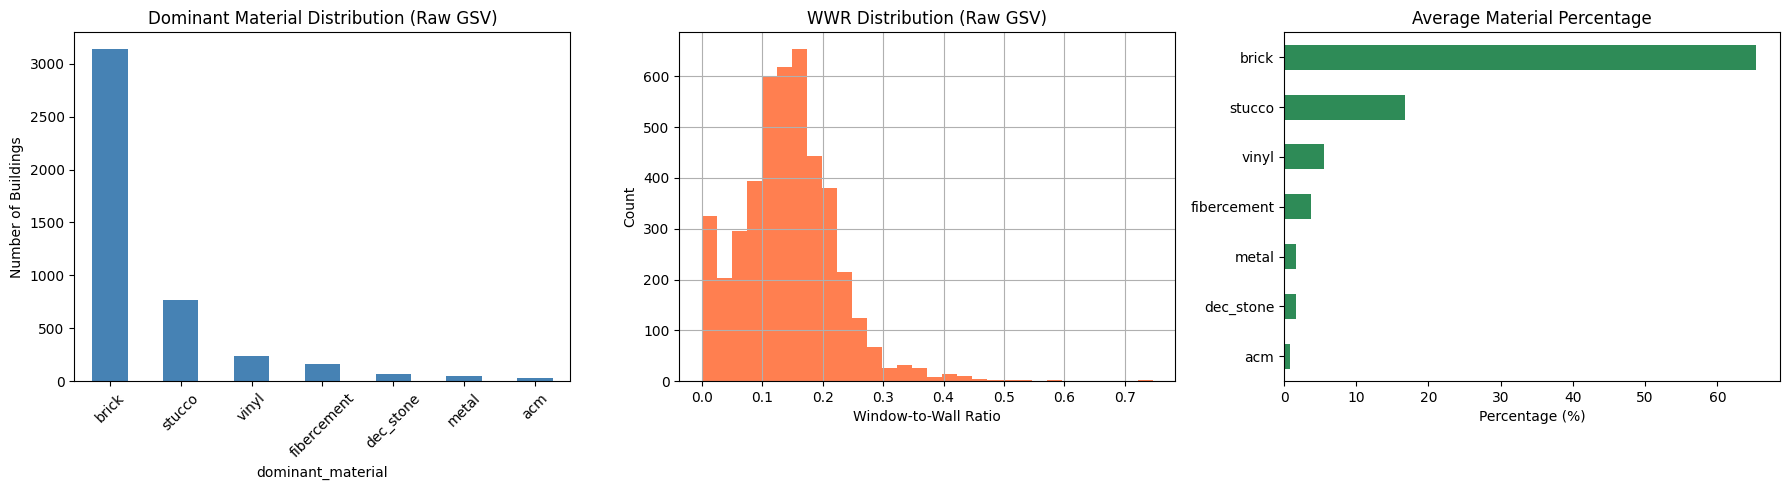

In [ ]:
# ============================================================
# Cell 23: Overview plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Dominant material counts
ax1 = axes[0]
df_raw["dominant_material"].value_counts().plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_title("Dominant Material Distribution (Raw GSV)")
ax1.set_ylabel("Number of Buildings")
ax1.tick_params(axis='x', rotation=45)

# Plot 2: WWR distribution
ax2 = axes[1]
df_raw["wwr"].dropna().hist(bins=30, ax=ax2, color="coral")
ax2.set_title("WWR Distribution (Raw GSV)")
ax2.set_xlabel("Window-to-Wall Ratio")
ax2.set_ylabel("Count")

# Plot 3: Average material percentages
ax3 = axes[2]
mat_cols = [f"pct_{m}" for m in ALL_MATERIALS]
avg_pcts = df_raw[mat_cols].mean().sort_values(ascending=True)
avg_pcts.index = [c.replace("pct_", "") for c in avg_pcts.index]
avg_pcts.plot(kind="barh", ax=ax3, color="seagreen")
ax3.set_title("Average Material Percentage")
ax3.set_xlabel("Percentage (%)")

plt.tight_layout()
plt.savefig("results_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Fix filename mismatch between curated images and COCO export
# ============================================================
# Roboflow renames files like:
#   CMX_204_e_girard_jpg.rf.99216f64606a85ad8b9bf0a4e7e24c7b.jpg
# We need to convert back to:
#   CMX_204_e_girard.jpg

def clean_roboflow_filename(rf_name):
    """Convert Roboflow filename back to original filename."""
    # Remove everything from .rf. onward, keep final extension
    # CMX_1126_epalmer_png.rf.HASH.jpg → CMX_1126_epalmer_png
    base = rf_name.split(".rf.")[0]

    # Roboflow converts the original extension to an underscore
    # Check for any image extension at the end of the base name
    for ext in ["_png", "_jpg", "_jpeg", "_bmp", "_tiff"]:
        if base.endswith(ext):
            # Restore the original extension
            base = base[:-len(ext)] + ext.replace("_", ".")
            return base

    # If no known extension found, just add the final extension
    final_ext = rf_name.split(".")[-1]
    return base + "." + final_ext

# Apply to the WWR annotations dataframe
df_wwr_annotations["filename_original"] = df_wwr_annotations["filename"].apply(
    clean_roboflow_filename
)

# Verify
print("Examples:")
for _, row in df_wwr_annotations.head(5).iterrows():
    print(f"  {row['filename']}  →  {row['filename_original']}")

Examples:
  RS_1345_montgomery_jpg.rf.4e9394407a4d5040ac39d563e485a8e3.jpg  →  RS_1345_montgomery.jpg
  CMX_2216_frank_update_jpg.rf.dfeb7ea70c3f223f9bec9d9102ff5d68.jpg  →  CMX_2216_frank_update.jpg
  CMX_1853_blair_png.rf.2d904c976437a8a7e8a488120ea06310.jpg  →  CMX_1853_blair.png
  RS_1310_e_hewson_png.rf.9d0d862373b10a0ece02d822a83b1e16.jpg  →  RS_1310_e_hewson.png
  RS_1118_ecol_jpg.rf.0bb9e7e6d2c3d03318959291ed8062b3.jpg  →  RS_1118_ecol.jpg


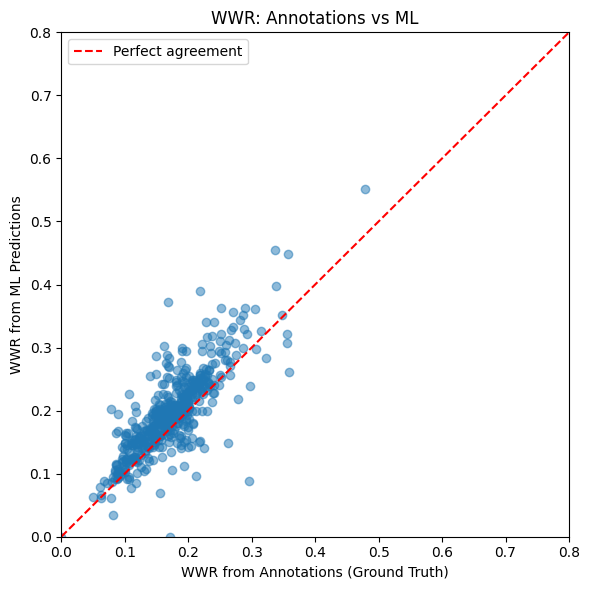

WWR Mean Absolute Error: 0.0381
Number of images compared: 473


In [ ]:
# ============================================================
# Cell 24: WWR comparison — annotations vs ML predictions
# ============================================================
# For curated images, compare the ground truth WWR (from annotations)
# against ML-predicted WWR. This shows how reliable the ML WWR is.

# Get ML-predicted WWR for curated images
curated_folder_path = "/content/drive/MyDrive/Facade Material Seg/curated images_merged"  # <-- same path
image_files = glob.glob(os.path.join(curated_folder_path, "*.jpg")) + \
              glob.glob(os.path.join(curated_folder_path, "*.png")) + \
              glob.glob(os.path.join(curated_folder_path, "*.jpeg"))

ml_wwr_results = []
for img_path in image_files:
    wwr_ml = get_wwr_from_predictions(best_model, img_path)
    ml_wwr_results.append({
        "filename": os.path.basename(img_path),
        "wwr_ml": wwr_ml
    })

df_ml_wwr = pd.DataFrame(ml_wwr_results)

# Merge with annotation-based WWR
df_wwr_compare = df_wwr_annotations[["filename_original", "wwr"]].rename(
    columns={"filename_original": "filename", "wwr": "wwr_annotation"}
).merge(df_ml_wwr, on="filename", how="inner")

# Plot comparison
if len(df_wwr_compare) > 0:
    valid = df_wwr_compare.dropna(subset=["wwr_annotation", "wwr_ml"])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(valid["wwr_annotation"], valid["wwr_ml"], alpha=0.5)
    ax.plot([0, 1], [0, 1], "r--", label="Perfect agreement")
    ax.set_xlabel("WWR from Annotations (Ground Truth)")
    ax.set_ylabel("WWR from ML Predictions")
    ax.set_title("WWR: Annotations vs ML")
    ax.legend()
    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 0.8)
    plt.tight_layout()
    plt.savefig("wwr_comparison.png", dpi=150)
    plt.show()

    mae = (valid["wwr_annotation"] - valid["wwr_ml"]).abs().mean()
    print(f"WWR Mean Absolute Error: {mae:.4f}")
    print(f"Number of images compared: {len(valid)}")
else:
    print("No matching filenames found between annotations and curated images.")
    print("Check that filenames match between your COCO export and image folder.")

In [ ]:
# Check what's not matching
curated_filenames = set(df_ml_wwr["filename"].values)
annotation_filenames = set(df_wwr_annotations["filename_original"].values)

# Files in curated but not in annotations
missing_from_annotations = curated_filenames - annotation_filenames
# Files in annotations but not in curated
missing_from_curated = annotation_filenames - curated_filenames

print(f"Curated images: {len(curated_filenames)}")
print(f"Annotation images: {len(annotation_filenames)}")
print(f"Matched: {len(curated_filenames & annotation_filenames)}")
print(f"\nIn curated but NOT in annotations: {len(missing_from_annotations)}")
print(f"In annotations but NOT in curated: {len(missing_from_curated)}")

# Show examples of mismatches
print("\nSample unmatched curated filenames:")
for fn in sorted(missing_from_annotations)[:5]:
    print(f"  {fn}")

print("\nSample unmatched annotation filenames:")
for fn in sorted(missing_from_curated)[:5]:
    print(f"  {fn}")

Curated images: 477
Annotation images: 483
Matched: 475

In curated but NOT in annotations: 2
In annotations but NOT in curated: 8

Sample unmatched curated filenames:
  CMX_419_e_gir .jpg
  RS_1235_day.png

Sample unmatched annotation filenames:
  CMX_2229_trent.png
  CMX_2231_trent.png
  CMX_2231_trent_update.png
  CMX_419_e_gir-.jpg
  RS_1225_day.png


---
## Part 9: Download Everything

In [ ]:
# ============================================================
# Cell 25: Download everything from Google Drive
# ============================================================
save_dir = "/content/drive/MyDrive/facade_model_backup/"

# Download model weights
files.download(f"{save_dir}/best.pt")

# Download CSVs and visuals
for csv_file in ["curated_wwr_from_annotations.csv",
                 "curated_material_ratios.csv",
                 "curated_full_results.csv",
                 "raw_gsv_results.csv",
                 "results_overview.png",
                 "wwr_comparison.png"]:
    # Check both Drive and local
    if os.path.exists(os.path.join(save_dir, csv_file)):
        files.download(os.path.join(save_dir, csv_file))
    elif os.path.exists(csv_file):
        files.download(csv_file)
    else:
        print(f"Not found: {csv_file}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Cell 26: Save to Google Drive (alternative)
# ============================================================
# Uncomment to save everything to Drive instead of downloading:

# save_dir = "/content/drive/MyDrive/facade_model_results/"
# os.makedirs(save_dir, exist_ok=True)
#
# import shutil
# shutil.copy(f"{HOME}/runs/segment/facade_seg/weights/best.pt",
#             f"{save_dir}/best.pt")
#
# for f in ["curated_wwr_from_annotations.csv",
#           "curated_material_ratios.csv",
#           "curated_full_results.csv",
#           "raw_gsv_results.csv",
#           "results_overview.png",
#           "wwr_comparison.png"]:
#     if os.path.exists(f):
#         shutil.copy(f, os.path.join(save_dir, f))
#
# print(f"All saved to {save_dir}")

# Save all current CSVs and visuals to Drive
save_dir = "/content/drive/MyDrive/facade_model_backup/"

for f in ["curated_wwr_from_annotations.csv",
          "curated_material_ratios.csv",
          "curated_full_results.csv",
          "raw_gsv_results.csv",
          "results_overview.png",
          "wwr_comparison.png"]:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(save_dir, f))
        print(f"Saved: {f}")
    else:
        print(f"Not found locally: {f}")

print("\nEverything backed up to Drive!")

Saved: curated_wwr_from_annotations.csv
Saved: curated_material_ratios.csv
Saved: curated_full_results.csv
Not found locally: raw_gsv_results.csv
Saved: results_overview.png
Saved: wwr_comparison.png

Everything backed up to Drive!


---
## Part 10: Domain Adaptation (After First Results)

After reviewing raw GSV results:
1. Look at images where `status` ≠ "success"
2. Pick 40–50 raw GSV images (mix of successes and failures)
3. Upload to Roboflow, annotate with polygons
4. Generate new version, retrain

In [ ]:
# ============================================================
# Cell 27: Inspect failures
# ============================================================
failures = df_raw[df_raw["status"] != "success"]
print(f"Total failures: {len(failures)}")
print(f"\nFailure types:")
print(failures["status"].value_counts().to_string())

if len(failures) > 0:
    print("\nSample failed filenames (annotate these in Roboflow):")
    for fn in failures["filename"].head(15).values:
        print(f"  {fn}")

Total failures: 210

Failure types:
status
no_materials_found    123
no_detections          87

Sample failed filenames (annotate these in Roboflow):
  413 E GIRARD AVE.jpg
  2213 CEDAR ST.jpg
  1523-25 E BERKS ST.jpg
  1449 E MONTGOMERY AVE.jpg
  2011-13 FRANKFORD AVE.jpg
  2020-24 FRANKFORD AVE.jpg
  25 E OXFORD ST.jpg
  2533 E DAKOTA ST.jpg
  1222-34 N DELAWARE AVE.jpg
  448 E THOMPSON ST.jpg
  2141 E NORRIS ST.jpg
  2310 MEMPHIS ST.jpg
  1348 E OXFORD ST.jpg
  2300 FRANKFORD AVE.jpg
  1250 E PALMER ST.jpg


In [ ]:
# ============================================================
# Diagnose WHY images are failing
# ============================================================
# Pick 5 failed images and see what the model actually detects
# before the center-building logic filters things out

sample_failures = failures.head(5)

for _, row in sample_failures.iterrows():
    img_path = os.path.join(raw_folder, row["filename"])
    if not os.path.exists(img_path):
        print(f"File not found: {row['filename']}")
        continue

    print(f"\n{'='*50}")
    print(f"Image: {row['filename']}  |  Status: {row['status']}")

    results = best_model.predict(img_path, imgsz=1280, conf=0.25,
                                  retina_masks=True, verbose=False)[0]

    if results.masks is None:
        print("  Model detected NOTHING at all")
    else:
        print(f"  Total detections: {len(results.masks.data)}")
        class_names = best_model.names
        for i, cls_id in enumerate(results.boxes.cls):
            name = class_names[int(cls_id)]
            conf = results.boxes.conf[i].item()
            box = results.boxes.xyxy[i]
            center_x = ((box[0] + box[2]) / 2).item()
            print(f"    {name} (conf={conf:.2f}, center_x={center_x:.0f})")

    # Also save the visual prediction
    best_model.predict(img_path, imgsz=1280, conf=0.25,
                        retina_masks=True, save=True,
                        name=f"debug_{row['filename'].split('.')[0]}")

print("\nVisual predictions saved to runs/segment/ folders")


Image: 1124 E COLUMBIA AVE.jpg  |  Status: no_materials_found
  Total detections: 19
    brick (conf=0.93, center_x=353)
    window (conf=0.91, center_x=310)
    window (conf=0.91, center_x=134)
    window (conf=0.90, center_x=206)
    window (conf=0.90, center_x=195)
    window (conf=0.89, center_x=383)
    window (conf=0.89, center_x=400)
    window (conf=0.89, center_x=133)
    window (conf=0.88, center_x=334)
    window (conf=0.88, center_x=481)
    window (conf=0.86, center_x=195)
    window (conf=0.83, center_x=480)
    window (conf=0.82, center_x=545)
    brick (conf=0.80, center_x=138)
    window (conf=0.72, center_x=537)
    brick (conf=0.68, center_x=535)
    window (conf=0.55, center_x=337)
    window (conf=0.51, center_x=119)
    window (conf=0.25, center_x=188)
Results saved to /content/runs/segment/debug_1124 E COLUMBIA AVE

Image: 1125 E MONTGOMERY AVE.jpg  |  Status: no_materials_found
  Total detections: 22
    window (conf=0.92, center_x=35)
    window (conf=0.91, ce

In [ ]:
# Check if materials appear at lower confidence
#If materials appear at conf 0.05–0.20 → The model recognizes the materials but isn't confident. Simply lowering confidence in the inference functions from conf=0.25 to conf=0.10 or conf=0.15 could fix most of your 1322 "no_materials_found" failures in one line.
#If still no materials even at 0.05 → This is a real domain gap. The raw GSV images look too different from your curated training images.
#The model literally doesn't recognize materials at that zoom level/angle. This is where the domain adaptation (annotating 40–50 raw images) becomes necessary.

for img_name in ["1124 E COLUMBIA AVE.jpg", "1125 SHACKAMAXON ST.jpg"]:
    img_path = os.path.join(raw_folder, img_name)
    if not os.path.exists(img_path):
        continue

    print(f"\n{'='*50}")
    print(f"Image: {img_name}")

    # Try very low confidence
    results = best_model.predict(img_path, imgsz=1280, conf=0.05,
                                  retina_masks=True, verbose=False)[0]

    if results.masks is not None:
        class_names = best_model.names
        for i, cls_id in enumerate(results.boxes.cls):
            name = class_names[int(cls_id)]
            conf = results.boxes.conf[i].item()
            if name != "window":
                print(f"  MATERIAL: {name} (conf={conf:.3f})")

        window_count = sum(1 for c in results.boxes.cls
                          if class_names[int(c)] == "window")
        print(f"  (plus {window_count} windows)")
    else:
        print("  Still nothing even at conf=0.05")


Image: 1124 E COLUMBIA AVE.jpg
  MATERIAL: brick (conf=0.925)
  MATERIAL: brick (conf=0.803)
  MATERIAL: brick (conf=0.680)
  (plus 18 windows)

Image: 1125 SHACKAMAXON ST.jpg
  MATERIAL: fibercement (conf=0.924)
  MATERIAL: brick (conf=0.890)
  MATERIAL: metal (conf=0.876)
  MATERIAL: stucco (conf=0.699)
  MATERIAL: metal (conf=0.662)
  MATERIAL: brick (conf=0.543)
  MATERIAL: brick (conf=0.486)
  MATERIAL: brick (conf=0.216)
  MATERIAL: fibercement (conf=0.208)
  MATERIAL: brick (conf=0.191)
  MATERIAL: fibercement (conf=0.092)
  (plus 24 windows)


In [ ]:
# ============================================================
# Pick 50 images for domain adaptation
# ============================================================
import shutil

# Create a folder on Drive to collect them
adapt_dir = "/content/drive/MyDrive/domain_adaptation_images/"
os.makedirs(adapt_dir, exist_ok=True)

# 30 failed images
failed_samples = df_raw[df_raw["status"] != "success"].sample(30, random_state=42)

# 20 successful images
success_samples = df_raw[df_raw["status"] == "success"].sample(20, random_state=42)

# Copy them all to one folder on Drive
copied = 0
for _, row in pd.concat([failed_samples, success_samples]).iterrows():
    src = os.path.join(raw_folder, row["filename"])
    if os.path.exists(src):
        shutil.copy(src, os.path.join(adapt_dir, row["filename"]))
        copied += 1

print(f"Copied {copied} images to {adapt_dir}")
print(f"\n30 Failed images:")
for fn in failed_samples["filename"].values:
    print(f"  {fn}")
print(f"\n20 Successful images:")
for fn in success_samples["filename"].values:
    print(f"  {fn}")

Copied 50 images to /content/drive/MyDrive/domain_adaptation_images/

30 Failed images:
  1512 E PALMER ST.jpg
  1247 E FLETCHER ST.jpg
  1226-28 LEOPARD ST.jpg
  1024 E PALMER ST.jpg
  2217 E SUSQUEHANNA AVE.jpg
  539 E GIRARD AVE.jpg
  823 MERCER ST.jpg
  115 E GIRARD AVE.jpg
  1356 E COLUMBIA AVE.jpg
  1559 E MONTGOMERY AVE.jpg
  1523-27 FRANKFORD AVE.jpg
  825 LIVINGSTON ST.jpg
  2211 E NORRIS ST.jpg
  859 MERCER ST.jpg
  1436 E COLUMBIA AVE.jpg
  1109 SHACKAMAXON ST.jpg
  1123 LEOPARD ST.jpg
  2008 TULIP ST.jpg
  1343 E PALMER ST.jpg
  2625 E DAUPHIN ST.jpg
  440 MILLER ST.jpg
  1351 E OXFORD ST.jpg
  526 BELGRADE ST.jpg
  1341 E COLUMBIA AVE.jpg
  1122-38 E SUSQUEHANNA AVE.jpg
  2628 E YORK ST.jpg
  2215 E SUSQUEHANNA AVE.jpg
  7 EARL CT.jpg
  1256 E COLUMBIA AVE.jpg
  1528 E MONTGOMERY AVE.jpg

20 Successful images:
  1605 E EYRE ST.jpg
  1105 E EYRE ST.jpg
  1587 E HEWSON ST.jpg
  1651 E BERKS ST.jpg
  720 MOYER ST.jpg
  1116 E EYRE ST.jpg
  925 MARLBOROUGH ST.jpg
  2032 BLAIR 

---
## Part 11: Label Efficiency Experiment

Train with N = 50, 100, 200, 300, all images using identical hyperparameters. Compare against zero-shot baseline.

**Before running:** Create stratified subsets in Roboflow (separate versions) ensuring every material class is represented in each subset.

In [ ]:
# ============================================================
# Cell 28: Label efficiency experiment
# ============================================================
# Create Roboflow versions for each budget BEFORE running this.
# Each version should have the same test/valid set but fewer
# training images.

# Map budget to Roboflow version number:
budget_versions = {
    50: 1,    # <-- update these version numbers
    100: 2,
    200: 3,
    300: 4,
}

label_eff_results = []

for n, version_num in budget_versions.items():
    print(f"\n{'=' * 50}")
    print(f"Training with N = {n} images")
    print(f"{'=' * 50}")

    subset = project.version(version_num).download("yolov8")

    m = YOLO("yolov8m-seg.pt")
    m.train(
        data=f"{subset.location}/data.yaml",
        epochs=200,
        patience=50,
        imgsz=1280,
        batch=8,
        device=0,
        name=f"label_eff_n{n}",
        flipud=0.0,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.1,
        degrees=10.0,
        hsv_h=0.015,
        hsv_s=0.4,
        hsv_v=0.4,
    )

    # Evaluate on SAME test set
    trained = YOLO(f"runs/segment/label_eff_n{n}/weights/best.pt")
    val_metrics = trained.val(data=f"{dataset.location}/data.yaml")

    label_eff_results.append({
        "n_images": n,
        "mask_map50": val_metrics.seg.map50,
        "mask_map50_95": val_metrics.seg.map,
    })
    print(f"N={n} -> Mask mAP50: {val_metrics.seg.map50:.4f}")

df_eff = pd.DataFrame(label_eff_results)
df_eff.to_csv("label_efficiency.csv", index=False)
print(f"\nResults:")
print(df_eff)

In [ ]:
# ============================================================
# Cell 29: Plot label efficiency curve
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df_eff["n_images"], df_eff["mask_map50"], "bo-",
        linewidth=2, markersize=8, label="YOLO Mask mAP50")
ax.plot(df_eff["n_images"], df_eff["mask_map50_95"], "rs-",
        linewidth=2, markersize=8, label="YOLO Mask mAP50-95")

# Add zero-shot baseline as horizontal line
# REPLACE with your zero-shot team's results:
# ax.axhline(y=0.65, color="green", linestyle="--",
#            linewidth=2, label="Zero-shot baseline")

ax.set_xlabel("Number of Labeled Training Images", fontsize=12)
ax.set_ylabel("Performance", fontsize=12)
ax.set_title("Label Efficiency: YOLO vs Zero-Shot", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("label_efficiency_curve.png", dpi=150)
plt.show()

---
## Summary of Outputs

| File | What it contains |
|------|------------------|
| `best.pt` | Trained model weights — save this! |
| `curated_wwr_from_annotations.csv` | WWR for curated images from Roboflow polygons (ground truth) |
| `curated_material_ratios.csv` | Material percentages for curated images (from ML) |
| `curated_full_results.csv` | Combined: materials (ML) + WWR (annotations) |
| `raw_gsv_results.csv` | Materials + WWR for 5,000+ raw GSV images (center building only) |
| `wwr_comparison.png` | Scatter plot comparing annotation vs ML WWR |
| `results_overview.png` | Distribution plots for raw GSV results |
| `label_efficiency.csv` | Label efficiency experiment results |